In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = pd.read_csv('/content/sample_data/framingham.csv')
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
data.shape

(4238, 16)

In [4]:
data.keys()

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [6]:
data.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [7]:
data.isna().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [8]:
data.dropna(axis = 0, inplace = True)
print(data.shape)

(3656, 16)


In [64]:
data['TenYearCHD'].value_counts()

,count
TenYearCHD,
0,3099
1,557


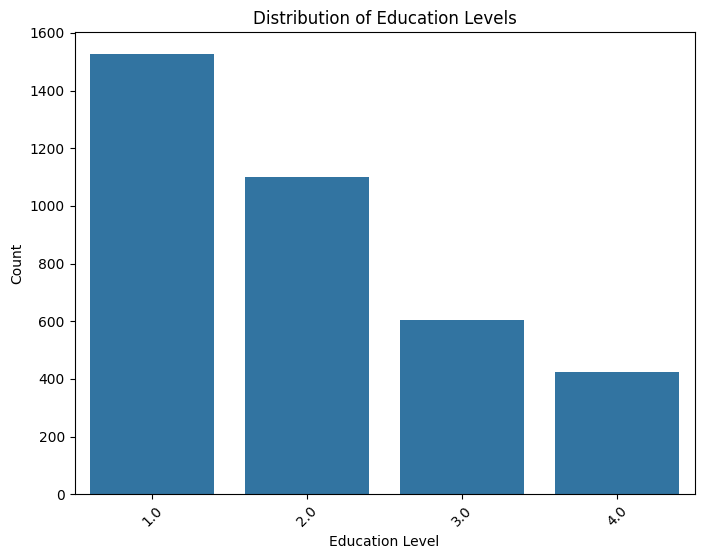

In [65]:
plt.figure(figsize=(8, 6))
sns.countplot(x='education', data=data)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Levels')
plt.xticks(rotation=45)
plt.show()

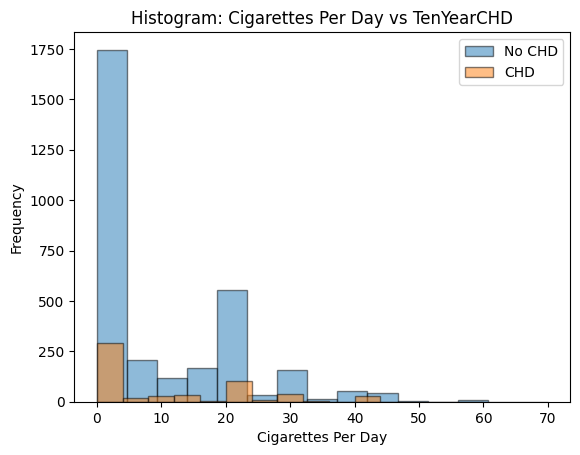

In [66]:
chd_no = data[data['TenYearCHD'] == 0]
chd_yes = data[data['TenYearCHD'] == 1]

plt.hist(chd_no['cigsPerDay'], bins=15, alpha=0.5, label='No CHD', edgecolor='black')
plt.hist(chd_yes['cigsPerDay'], bins=15, alpha=0.5, label='CHD', edgecolor='black')

plt.xlabel('Cigarettes Per Day')
plt.ylabel('Frequency')
plt.title('Histogram: Cigarettes Per Day vs TenYearCHD')
plt.legend()
plt.show()

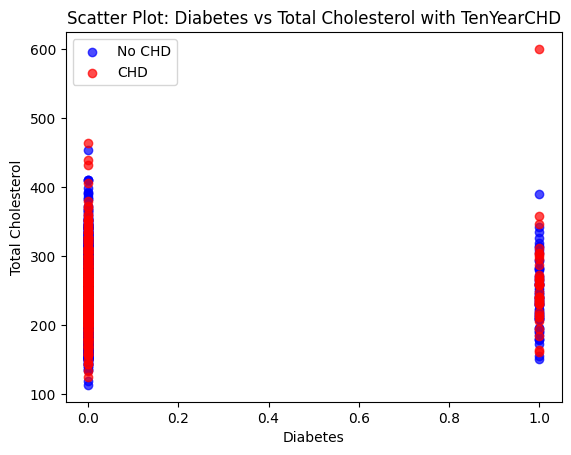

In [67]:

chd_no = data[data['TenYearCHD'] == 0]
chd_yes = data[data['TenYearCHD'] == 1]

plt.scatter(chd_no['diabetes'], chd_no['totChol'], label='No CHD', color='blue', alpha=0.7)
plt.scatter(chd_yes['diabetes'], chd_yes['totChol'], label='CHD', color='red', alpha=0.7)

plt.xlabel('Diabetes')
plt.ylabel('Total Cholesterol')
plt.title('Scatter Plot: Diabetes vs Total Cholesterol with TenYearCHD')
plt.legend()
plt.show()


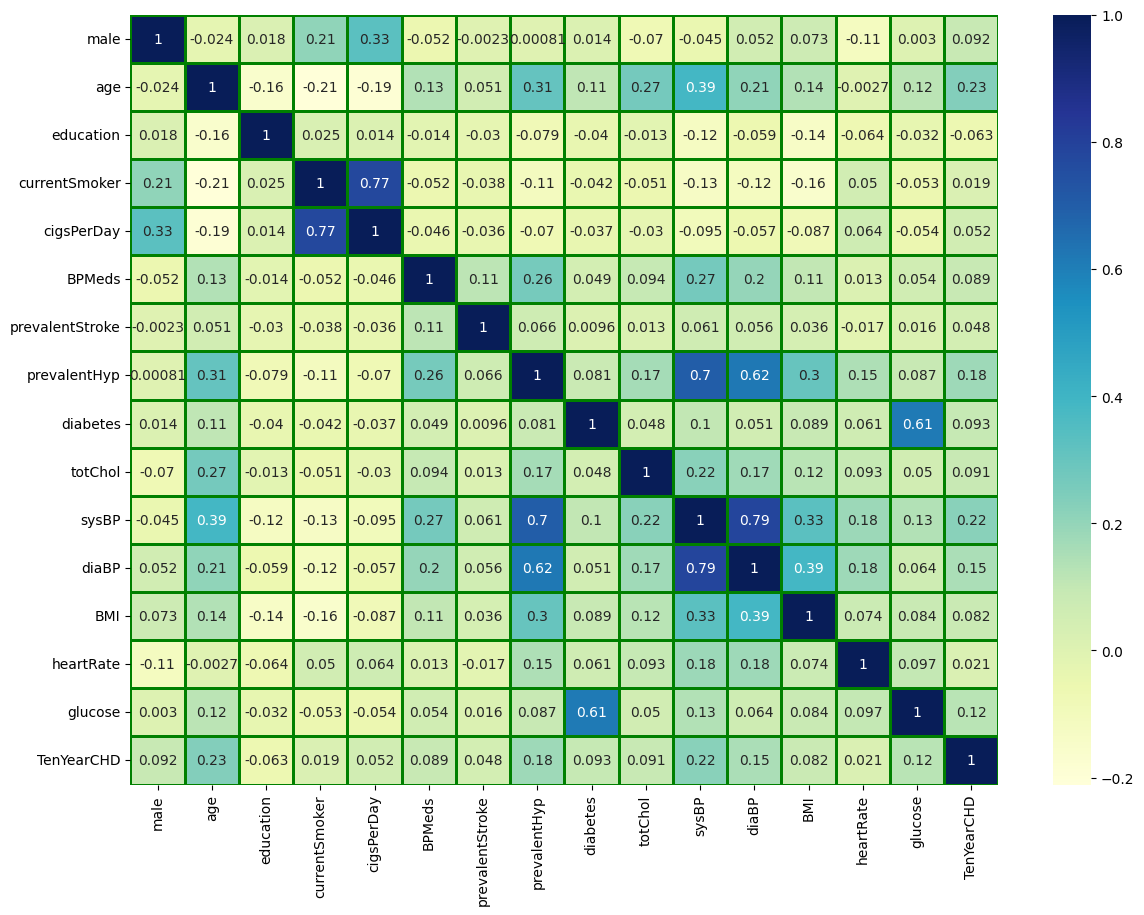

In [68]:
plt.figure(figsize = (14, 10))
sns.heatmap(data.corr(), cmap='YlGnBu',annot=True, linecolor='Green', linewidths=1.0)
plt.show()

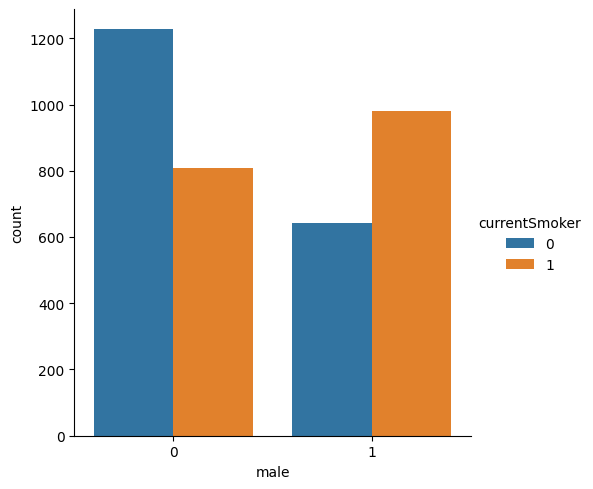

In [69]:
sns.catplot(data=data, kind='count', x='male',hue='currentSmoker')
plt.show()

/tmp/ipykernel_679/3045232516.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=data, kind='count', x='TenYearCHD', col='male',row='currentSmoker', palette='Blues')


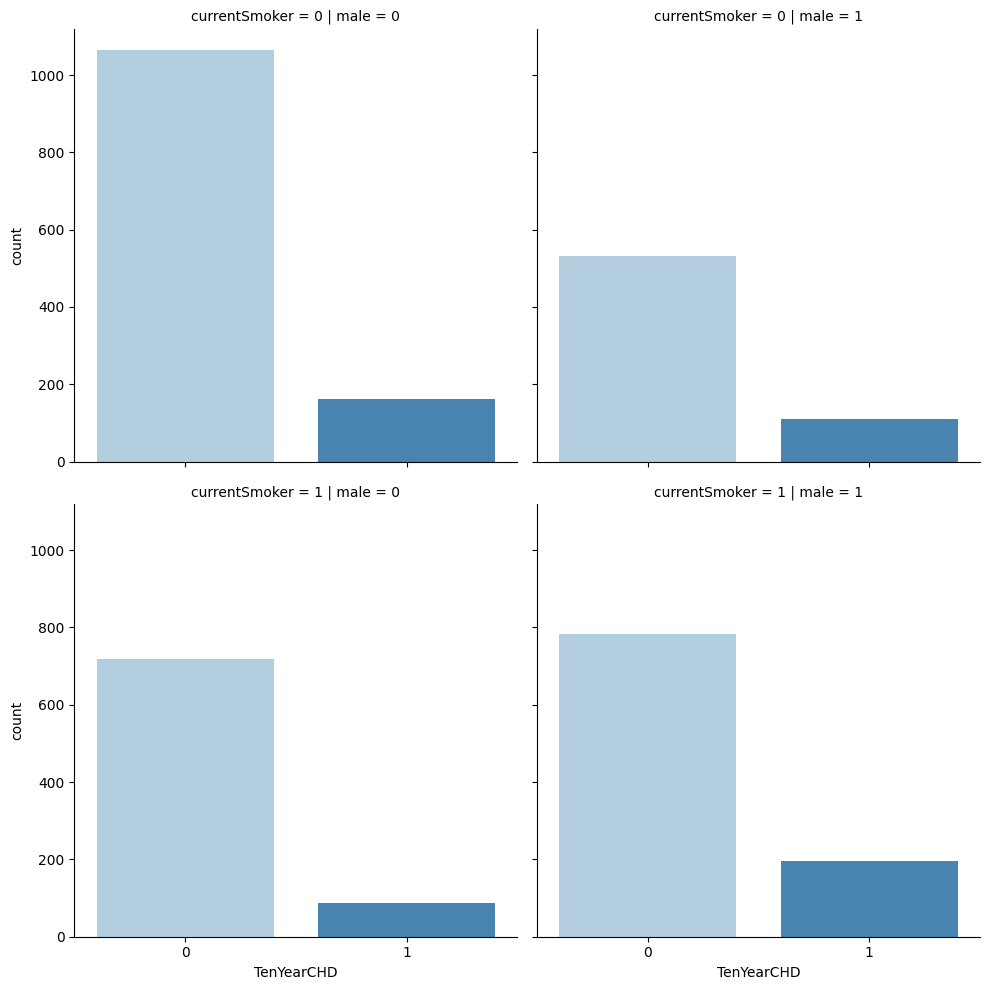

In [70]:
sns.catplot(data=data, kind='count', x='TenYearCHD', col='male',row='currentSmoker', palette='Blues')
plt.show()

### Data Analysis

In [71]:
correlation_with_chd = data.corr()['TenYearCHD'].sort_values(ascending=False)
display(correlation_with_chd)

,TenYearCHD
TenYearCHD,1.000000
age,0.233810
sysBP,0.222885
prevalentHyp,0.181556
diaBP,0.150342
glucose,0.121942
diabetes,0.093397
male,0.091745
totChol,0.091127
BPMeds,0.089116


The correlation analysis shows that `age`, `sysBP`, `glucose`, `diaBP`, `cigsPerDay`, `male`, `BMI`, and `totChol` have positive correlations with `TenYearCHD`, with `age` and `sysBP` being the most strongly correlated. `education`, `heartRate`, `currentSmoker`, and `BPMeds` have weaker positive correlations. `prevalentHyp` and `diabetes` also show a positive correlation. Let's visualize the distribution of some of these key features in relation to `TenYearCHD`.

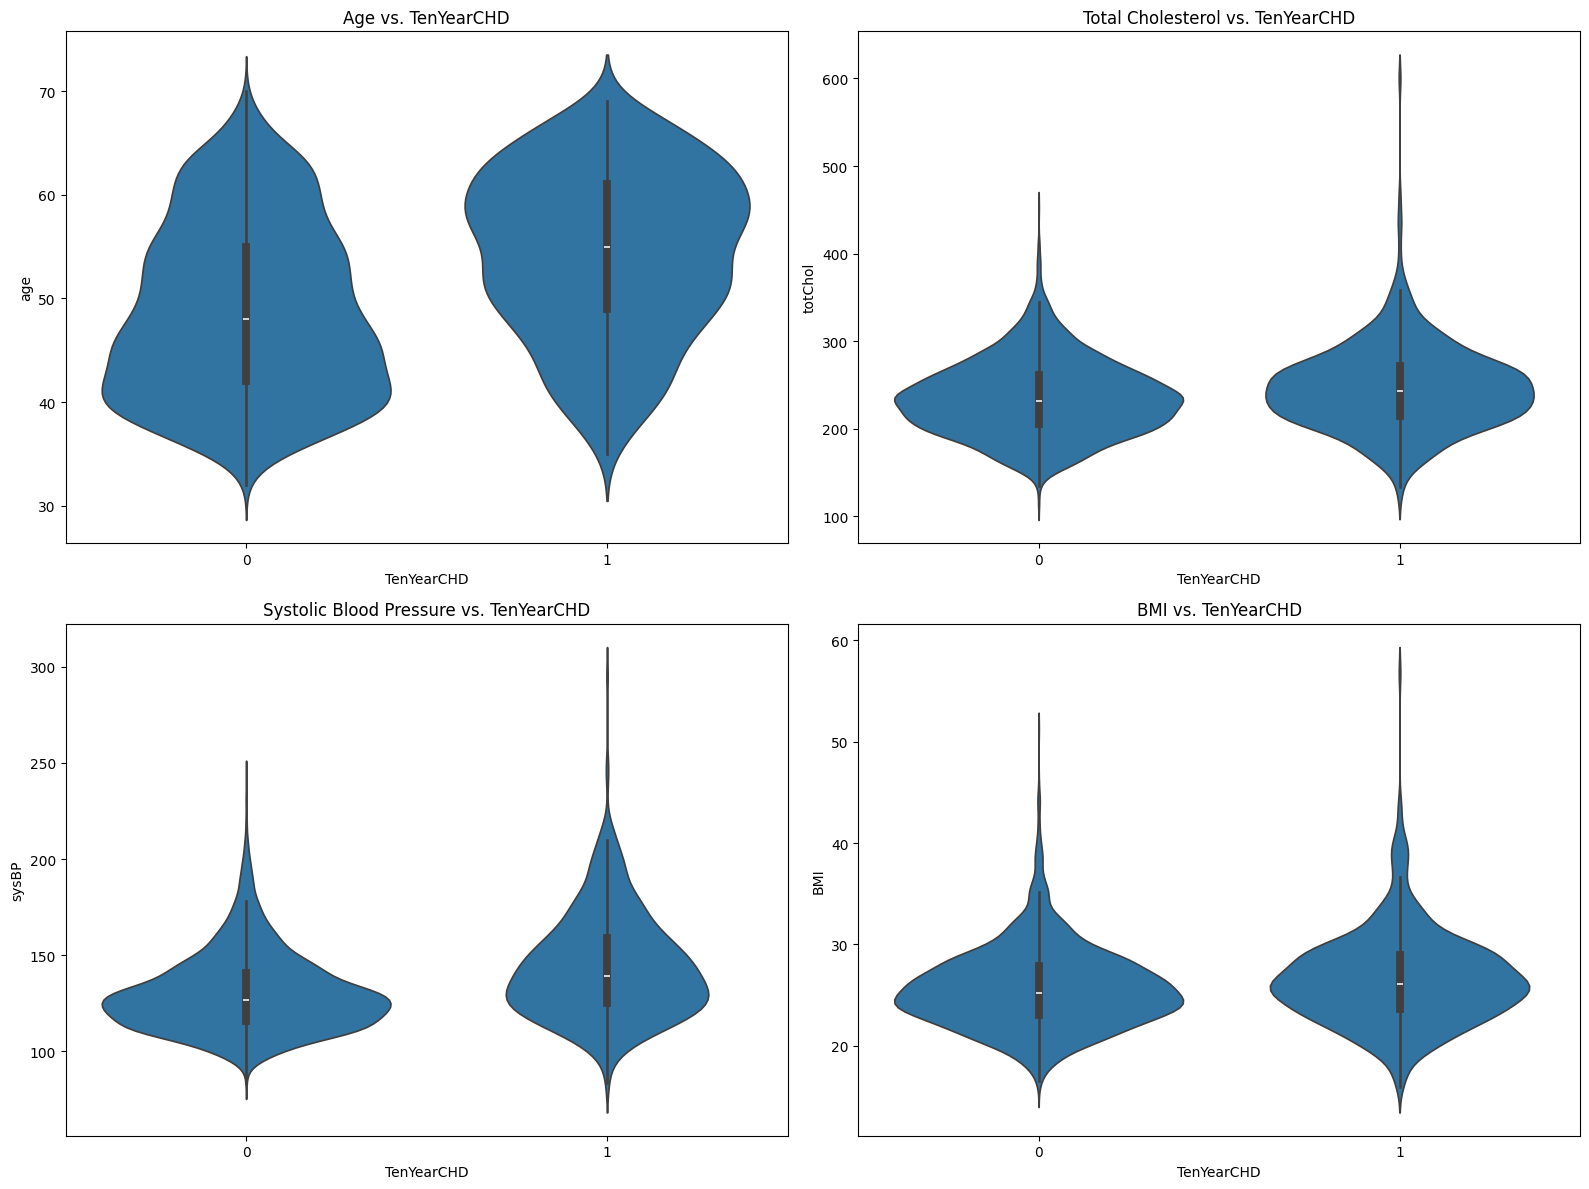

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.violinplot(x='TenYearCHD', y='age', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Age vs. TenYearCHD')

sns.violinplot(x='TenYearCHD', y='totChol', data=data, ax=axes[0, 1])
axes[0, 1].set_title('Total Cholesterol vs. TenYearCHD')

sns.violinplot(x='TenYearCHD', y='sysBP', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Systolic Blood Pressure vs. TenYearCHD')

sns.violinplot(x='TenYearCHD', y='BMI', data=data, ax=axes[1, 1])
axes[1, 1].set_title('BMI vs. TenYearCHD')

plt.tight_layout()
plt.show()

From the violin plots, we can observe the following trends:
- **Age**: The distribution for individuals with TenYearCHD tends to be shifted towards older ages, which aligns with the positive correlation.
- **Total Cholesterol (totChol)**: There appears to be a slight shift towards higher cholesterol levels in the CHD group, though the overlap is significant.
- **Systolic Blood Pressure (sysBP)**: Individuals with TenYearCHD show a clear tendency towards higher systolic blood pressure, reinforcing its strong positive correlation.
- **BMI**: While there's an overlap, the distribution for the CHD group might show a slight increase in BMI compared to the non-CHD group.

Next, let's look at the distribution of other numerical features with KDE plots to see how they differ between the two target classes.

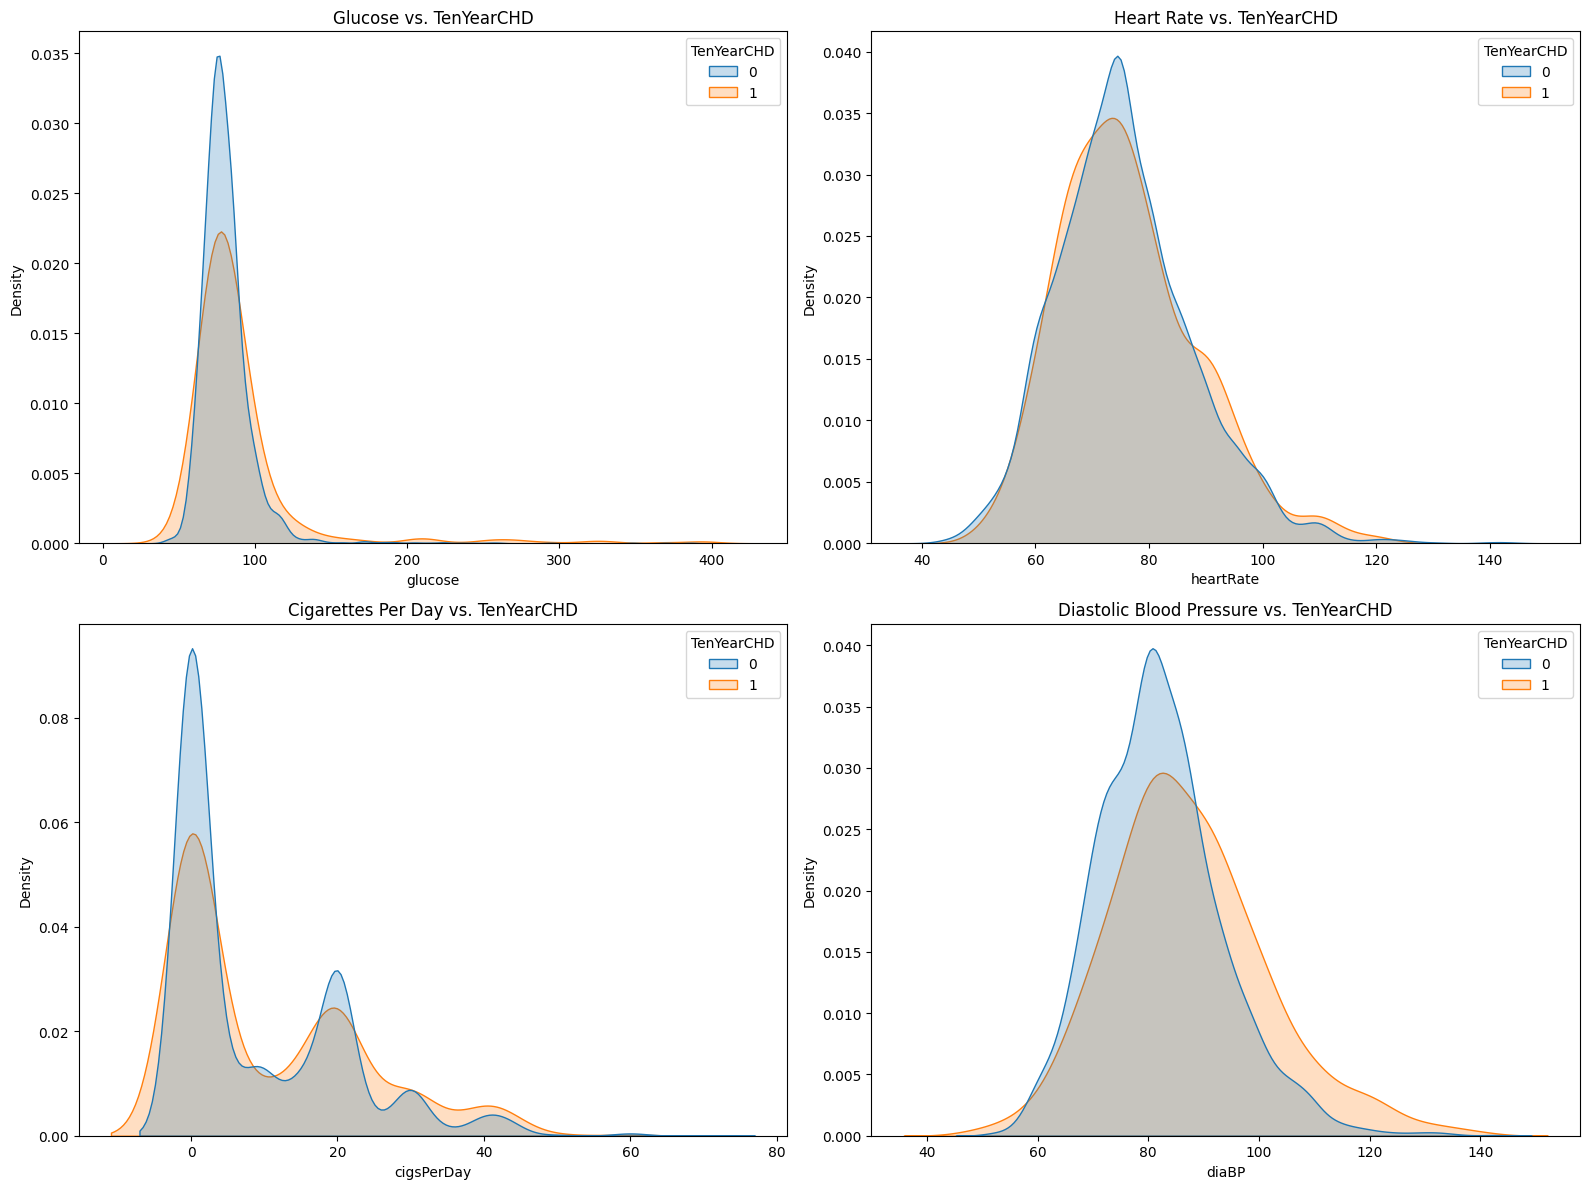

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.kdeplot(x='glucose', hue='TenYearCHD', data=data, fill=True, common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title('Glucose vs. TenYearCHD')

sns.kdeplot(x='heartRate', hue='TenYearCHD', data=data, fill=True, common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title('Heart Rate vs. TenYearCHD')

sns.kdeplot(x='cigsPerDay', hue='TenYearCHD', data=data, fill=True, common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title('Cigarettes Per Day vs. TenYearCHD')

sns.kdeplot(x='diaBP', hue='TenYearCHD', data=data, fill=True, common_norm=False, ax=axes[1, 1])
axes[1, 1].set_title('Diastolic Blood Pressure vs. TenYearCHD')

plt.tight_layout()
plt.show()

### Machine Learning Part

In [94]:
X = data.iloc[:,0:15]
y = data.iloc[:,15:16]

Machine Learning Part

In [75]:
X = data.iloc[:,0:15]
y = data.iloc[:,15:16]

In [76]:
X.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [77]:
y.head()

,TenYearCHD
0,0
1,0
2,0
3,1
4,0


Importing the model and assigning the data for training and test set

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=21)

In [79]:

from sklearn.preprocessing import StandardScaler
cs=StandardScaler()
X_train=cs.fit_transform(X_train)
X_test=cs.transform(X_test)

Logistic Regression(ML Model)

In [80]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(class_weight='balanced',max_iter=1000)

Training the data

In [81]:
logreg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced', max_iter=1000)

Testing the data

In [82]:
y_pred = logreg.predict(X_test)
print(y_pred)

[0 0 1 ... 0 1 0]



Confusion Matrix


In [83]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix is:\n",cm)

Confusion Matrix is:
 [[641 287]
 [ 62 107]]


In [84]:
score = logreg.score(X_test, y_test)
print("Prediction score is:",score)

Prediction score is: 0.6818596171376481


In [93]:
from sklearn.metrics import recall_score
recall  = recall_score(y_test, y_pred)
print("Recall score is:",recall)
print(107/(107+62))

Recall score is: 0.6331360946745562
0.6331360946745562


In [85]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=21)

In [86]:
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=21)

In [87]:
rf_predictions = rf_model.predict(X_test)
print(rf_predictions)

[0 0 0 ... 0 0 0]


In [88]:
from sklearn.metrics import confusion_matrix

# Assuming rf_predictions contains the predictions

# Generating the confusion matrix
conf_matrix = confusion_matrix(y_test, rf_predictions)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[924   4]
 [159  10]]


In [89]:
from sklearn.metrics import accuracy_score

# Assuming y_test contains the actual labels and rf_predictions contains the predictions

# Calculating accuracy
accuracy = accuracy_score(y_test, rf_predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8514129443938013


In [31]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
svm_model = SVC(kernel='rbf',class_weight='balanced')  # You can change the kernel type as needed


In [59]:
print(y_train.value_counts())

TenYearCHD
0             2171
1              388
Name: count, dtype: int64


In [60]:

svm_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(class_weight='balanced')

In [61]:
predictions = svm_model.predict(X_test)
print(predictions)

[1 0 1 ... 0 1 0]


In [62]:
from sklearn.metrics import confusion_matrix
# Generating the confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
# Displaying the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[654 274]
 [ 71  98]]


In [95]:
from sklearn.metrics import classification_report

print("Classification Report for SVM:")
print(classification_report(y_test, predictions))

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       928
           1       0.26      0.58      0.36       169

    accuracy                           0.69      1097
   macro avg       0.58      0.64      0.58      1097
weighted avg       0.80      0.69      0.73      1097



As the classification report shows, the SVM model has a very low recall for class 1 (TenYearCHD), indicating it struggles to identify positive cases. This is a common issue with imbalanced datasets. We need to improve this.

Let's try to improve the SVM model by performing hyperparameter tuning using GridSearchCV to find the best `C` and `gamma` values for the RBF kernel.

In [96]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Create a GridSearchCV object
grid = GridSearchCV(SVC(class_weight='balanced'), param_grid, refit=True, verbose=2, cv=3)

# Fit the model
grid.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters:", grid.best_params_)
print("Best Estimator Score:", grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s


...

[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.2s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.2s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best Estimator Score: 0.8378272762797968


In [97]:
# Get the best estimator and make predictions
grid_predictions = grid.predict(X_test)

# Evaluate the tuned SVM model
print("Confusion Matrix for Tuned SVM:")
print(confusion_matrix(y_test, grid_predictions))
print("\nClassification Report for Tuned SVM:")
print(classification_report(y_test, grid_predictions))

Confusion Matrix for Tuned SVM:
[[910  18]
 [163   6]]

Classification Report for Tuned SVM:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       928
           1       0.25      0.04      0.06       169

    accuracy                           0.84      1097
   macro avg       0.55      0.51      0.49      1097
weighted avg       0.76      0.84      0.78      1097



### Re-tuning SVM with Recall as the Scoring Metric

In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer

# Define the parameter grid for GridSearchCV
param_grid_recall = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Create a custom scorer for recall of the positive class (class 1)
recall_scorer = make_scorer(recall_score, pos_label=1)

# Create a GridSearchCV object, optimizing for recall
grid_recall = GridSearchCV(SVC(class_weight='balanced', probability=True), param_grid_recall, refit=True, verbose=2, cv=3, scoring=recall_scorer)

# Fit the model
grid_recall.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters for Recall Tuned SVM:", grid_recall.best_params_)
print("Best Estimator Recall Score:", grid_recall.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   1.0s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   1.5s


...

[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.8s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.8s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters for Recall Tuned SVM: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Estimator Recall Score: 1.0


In [99]:
# Get the best estimator and make predictions with the recall-tuned SVM
grid_recall_predictions = grid_recall.predict(X_test)

# Evaluate the recall-tuned SVM model
print("Confusion Matrix for Recall-Tuned SVM:")
print(confusion_matrix(y_test, grid_recall_predictions))
print("\nClassification Report for Recall-Tuned SVM:")
print(classification_report(y_test, grid_recall_predictions))

Confusion Matrix for Recall-Tuned SVM:
[[ 18 910]
 [  2 167]]

Classification Report for Recall-Tuned SVM:
              precision    recall  f1-score   support

           0       0.90      0.02      0.04       928
           1       0.16      0.99      0.27       169

    accuracy                           0.17      1097
   macro avg       0.53      0.50      0.15      1097
weighted avg       0.79      0.17      0.07      1097



In [63]:
from sklearn.metrics import accuracy_score
# Assuming y_test contains the actual labels and rf_predictions contains the predictions
# Calculating accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6855059252506837
